## 1. Введение
### 1.1 Цели и задачи проекта
#### Цель проекта

Провести исследовательский анализ данных Яндекс Афиши, чтобы выявить изменения пользовательского спроса и популярности мероприятий осенью 2024 года, а также сравнить поведение пользователей мобильных и стационарных устройств.

#### Задачи проекта

- Загрузить данные и оценить их объём, качество и соответствие описанию.
- Провести предобработку данных: обработать пропуски и дубликаты, проверить значения и типы данных, выявить выбросы.
- Привести выручку к единой валюте — российскому рублю — и рассчитать дополнительные показатели.
- Исследовать сезонные изменения количества заказов и распределения спроса по типам мероприятий, устройствам и возрастным категориям.
- Сравнить среднюю выручку с одного билета летом и осенью 2024 года.
- Проанализировать активность пользователей осенью: количество заказов, DAU, количество заказов на пользователя и среднюю стоимость билета.
- Исследовать недельную цикличность пользовательской активности.
- Определить наиболее популярные регионы и билетных партнёров по количеству мероприятий, заказов и выручке.
- Проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.
- Сформулировать основные выводы и рекомендации на основе результатов исследования.


### 1.2 Описание данных
датасет **final_tickets_orders_df.csv** включает информацию обо всех заказах билетов, совершённых с двух типов устройств
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev количество дней с предыдущей покупки для каждого пользователя.

датасет **final_tickets_events_df** содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год.
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).


## 2. Знакомство с данными
### 2.1 Загрузка данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu

import warnings

warnings.filterwarnings("ignore")
import jupyter_black

jupyter_black.load()

In [2]:
# выгружаем датасеты
df_orders = pd.read_csv(
    "https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv"
)
df_events = pd.read_csv(
    "https://code.s3.yandex.net/datasets/final_tickets_events_df.csv"
)
df_curs = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

In [3]:
# посмотрим на выгруженные датасеты
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 3

In [5]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


In [7]:
df_curs.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


**Датасет df_orders**: 14 столбцов и 290849 строк, данные полные, кроме столбца days_since_prev, нужно поменять тип данных в столбцах created_dt_msk и created_ts_msk на datetime, проверить наличие дубликатов и аномальных значений, строковые столбцы проверить на пробелы  
**Датасет df_events**: 11 столбцов и 22427 строк, данные полные, типы данных верные, проверить наличие дубликатов и аномальных значений, строковые столбцы проверить на пробелы  
**Датасет df_curs**: 4 столбца, 357 строк, данные полные, нужно поменять тип данных в столбце data на datetime  

После предобработки данных датасеты можно будет объединить


### 2.2 Предобработка данных и подготовка их к исследованию

In [9]:
# удаляем пробелы в начале и конце строковых значений
for df in [df_orders, df_events, df_curs]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

In [10]:
# проверим данные на наличие лишних значений
df_orders["device_type_canonical"].value_counts()

device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64

In [11]:
df_orders["currency_code"].value_counts()

currency_code
rub    285780
kzt      5069
Name: count, dtype: int64

In [12]:
df_orders["cinema_circuit"].value_counts()

cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64

In [13]:
# тк фильмы были исключены из датасета df_events, следует исключить столбец cinema_circuit
df_orders = df_orders.drop(columns="cinema_circuit")

In [14]:
# поменяем типы данных в столбцах с датой
df_orders["created_dt_msk"] = pd.to_datetime(df_orders["created_dt_msk"])
df_orders["created_ts_msk"] = pd.to_datetime(df_orders["created_ts_msk"])
df_curs["data"] = pd.to_datetime(df_curs["data"])

In [15]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  str           
 2   created_dt_msk         290849 non-null  datetime64[us]
 3   created_ts_msk         290849 non-null  datetime64[us]
 4   event_id               290849 non-null  int64         
 5   age_limit              290849 non-null  int64         
 6   currency_code          290849 non-null  str           
 7   device_type_canonical  290849 non-null  str           
 8   revenue                290849 non-null  float64       
 9   service_name           290849 non-null  str           
 10  tickets_count          290849 non-null  int64         
 11  total                  290849 non-null  float64       
 12  days_since_prev        268909 non-null  float64       


In [16]:
df_curs.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [17]:
# посмотрим на наличие выбросов по типу валют
df_orders.groupby("currency_code")["revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.1000,3698.83,7397.66,26425.86
rub,285780.0,547.568333,871.524559,-90.76,113.8275,346.10,791.70,81174.54


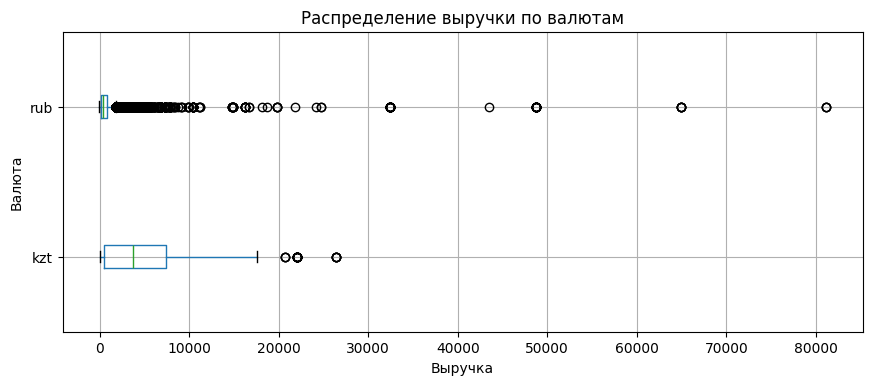

In [18]:
df_orders.boxplot(column="revenue", by="currency_code", vert=False, figsize=(10, 4))

plt.title("Распределение выручки по валютам")
plt.suptitle("")
plt.xlabel("Выручка")
plt.ylabel("Валюта")
plt.show()

In [19]:
# отберем значения по 99-му процентилю в revenue по валютам
rub_99 = df_orders.loc[df_orders["currency_code"] == "rub", "revenue"].quantile(0.99)

kzt_99 = df_orders.loc[df_orders["currency_code"] == "kzt", "revenue"].quantile(0.99)

df_orders = df_orders[
    ((df_orders["currency_code"] == "rub") & (df_orders["revenue"] <= rub_99))
    | ((df_orders["currency_code"] == "kzt") & (df_orders["revenue"] <= kzt_99))
].copy()

In [20]:
# посмотрим на выбросы по кол-ву билетов tickets_count
df_orders.groupby("currency_code")["tickets_count"].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5040.0,2.748413,1.101784,1.0,2.0,3.0,3.0,6.0
rub,282922.0,2.739737,1.163352,1.0,2.0,3.0,3.0,57.0


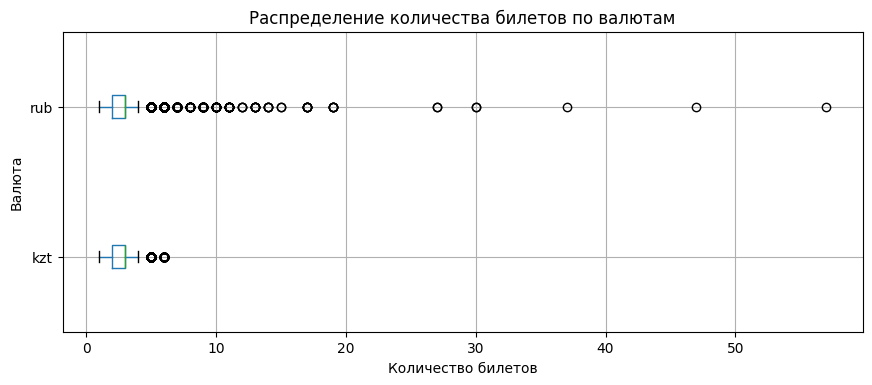

In [21]:
df_orders.boxplot(
    column="tickets_count", by="currency_code", vert=False, figsize=(10, 4)
)

plt.title("Распределение количества билетов по валютам")
plt.suptitle("")
plt.xlabel("Количество билетов")
plt.ylabel("Валюта")
plt.show()

In [22]:
# проверим на неявные дубликаты, не учитывая order_id
booking_cols = [
    "user_id",
    "created_dt_msk",
    "created_ts_msk",
    "event_id",
    "age_limit",
    "currency_code",
    "device_type_canonical",
    "revenue",
    "service_name",
    "tickets_count",
    "total",
    "days_since_prev",
]

df_orders.duplicated(subset=booking_cols).sum()

np.int64(30)

In [23]:
duplicates_booking = df_orders[
    df_orders.duplicated(subset=booking_cols, keep=False)
].sort_values(booking_cols)

duplicates_booking.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


результат показывает, что записи полностью совпадают по всем признакам бронирования и отличаются только order_id, что выглядит как техническая ошибка, их логично считать дубликатами и оставить по одной записи

In [24]:
df_orders = df_orders.drop_duplicates(subset=booking_cols, keep="first").copy()

In [25]:
df_orders.duplicated(subset=booking_cols).sum()

np.int64(0)

объединим обработанные датафреймы и добавим новые столбцы:  
**revenue_rub** — выручка с заказа в единой валюте — российский рубль.   
**one_ticket_revenue_rub** — выручка с продажи одного билета на мероприятие.  
**month** — месяц оформления заказа.  
**season** — информация о сезонности, включает такие категории, как: 'лето', 'осень', 'зима', 'весна'.  

In [26]:
df = df_orders.merge(df_events, on="event_id", how="inner")

In [27]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,16,rub,mobile,1521.94,Край билетов,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,0,rub,mobile,289.45,Мой билет,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,0,rub,mobile,1258.57,За билетом!,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,0,rub,mobile,8.49,Лови билет!,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,18,rub,mobile,1390.41,Билеты без проблем,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [28]:
df = df.merge(
    df_curs[["data", "curs"]], left_on="created_dt_msk", right_on="data", how="left"
)

In [29]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,...,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,curs
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,16,rub,mobile,1521.94,Край билетов,...,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,18.6972
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,0,rub,mobile,289.45,Мой билет,...,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,18.3419
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,0,rub,mobile,1258.57,За билетом!,...,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,0,rub,mobile,8.49,Лови билет!,...,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,18.5010
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,18,rub,mobile,1390.41,Билеты без проблем,...,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648


In [30]:
# создадим столбец revenue_rub
df["revenue_rub"] = df["revenue"]

df.loc[df["currency_code"] == "kzt", "revenue_rub"] = (
    df.loc[df["currency_code"] == "kzt", "revenue"]
    * df.loc[df["currency_code"] == "kzt", "curs"]
    / 100
)

In [31]:
df.loc[
    df["currency_code"] == "kzt", ["currency_code", "revenue", "curs", "revenue_rub"]
].head(10)

,currency_code,revenue,curs,revenue_rub
70,kzt,518.10,19.0125,98.503762
88,kzt,347.18,18.9330,65.731589
95,kzt,328.77,18.5991,61.148261
453,kzt,7397.66,19.9833,1478.296591
454,kzt,3698.83,19.9833,739.148295
455,kzt,7397.66,19.9833,1478.296591
456,kzt,5548.24,19.9833,1108.721444
457,kzt,7397.66,19.9833,1478.296591
507,kzt,361.08,18.4217,66.517074
508,kzt,361.08,18.4217,66.517074


In [32]:
# выручка с продажи одного билета one_ticket_revenue_rub
df["one_ticket_revenue_rub"] = df["revenue_rub"] / df["tickets_count"]

In [33]:
df[["revenue_rub", "tickets_count", "one_ticket_revenue_rub"]].head()

,revenue_rub,tickets_count,one_ticket_revenue_rub
0,1521.94,4,380.4850
1,289.45,2,144.7250
2,1258.57,4,314.6425
3,8.49,2,4.2450
4,1390.41,3,463.4700


In [34]:
# month — месяц оформления заказа
df["month"] = df["created_dt_msk"].dt.month

In [35]:
# season — информация о сезонности, включает такие категории, как: 'лето', 'осень', 'зима', 'весна'.
seasons = {6: "лето", 7: "лето", 8: "лето", 9: "осень", 10: "осень"}

df["season"] = df["month"].map(seasons)

In [36]:
df[["created_dt_msk", "month", "season"]].head(5)

,created_dt_msk,month,season
0,2024-08-20,8,лето
1,2024-07-23,7,лето
2,2024-10-06,10,осень
3,2024-07-13,7,лето
4,2024-10-04,10,осень


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287694 entries, 0 to 287693
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287694 non-null  int64         
 1   user_id                 287694 non-null  str           
 2   created_dt_msk          287694 non-null  datetime64[us]
 3   created_ts_msk          287694 non-null  datetime64[us]
 4   event_id                287694 non-null  int64         
 5   age_limit               287694 non-null  int64         
 6   currency_code           287694 non-null  str           
 7   device_type_canonical   287694 non-null  str           
 8   revenue                 287694 non-null  float64       
 9   service_name            287694 non-null  str           
 10  tickets_count           287694 non-null  int64         
 11  total                   287694 non-null  float64       
 12  days_since_prev         265988 non-null  

#### Промежуточный вывод 
После предобработки в датасете осталось **287 694 строки и 29 столбцов**. Изначально датасет содержал 290 849 строк, таким образом, в процессе очистки было удалено **3 155 строк**.  
Пропуски сохранились только в `days_since_prev`, они не были удалены, поскольку отсутствие значения может означать отсутствие предыдущего заказа пользователя, те это первый заказ.

В ходе предобработки были выполнены следующие действия:

* проверены явные и неявные дубликаты; технические дубликаты заказов были удалены;
* из исходных данных исключён столбец `cinema_circuit`, так как кинотеатры не рассматриваются в рамках анализа;
* даты приведены к формату `datetime`;
* для значений выручки выполнена фильтрация выбросов отдельно для каждой валюты по 99-му процентилю;
* выбросы по кол-ву билетов оставлены как есть, так как один человек вполне мог заказать большое кол-во билетов сразу, например, на организацию;
* были объединены датасеты с заказами и мероприятиями, а также датасет с курсом валют для конвертации валют к рублю;
* для заказов в тенге выполнен пересчёт выручки в рубли по курсу на дату заказа, при этом исходный столбец `revenue` сохранён;
* проверена полнота данных после объединения с таблицей курсов валют.

В результате были созданы новые признаки, которые проверены на полноту данных:

* `revenue_rub` — выручка в рублях;
* `one_ticket_revenue_rub` — выручка в рублях в расчёте на один билет;
* `month` — номер месяца оформления заказа;
* `season` — сезон оформления заказа.


## 3. Исследовательский анализ данных
### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

#### 3.1.1 Для каждого месяца найдем количество заказов и визуализируем результаты.

In [38]:
monthly_orders = df.groupby("month")["order_id"].count().reset_index()

monthly_orders

,month,order_id
0,6,34164
1,7,40404
2,8,44541
3,9,69322
4,10,99263


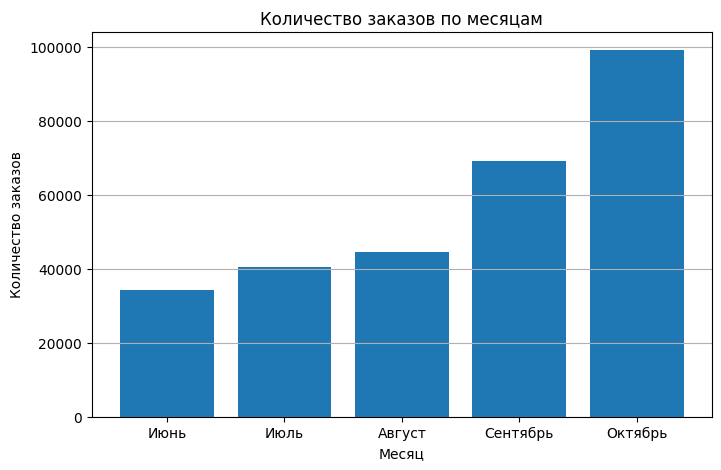

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(monthly_orders["month"], monthly_orders["order_id"])

plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.title("Количество заказов по месяцам")

plt.xticks([6, 7, 8, 9, 10], ["Июнь", "Июль", "Август", "Сентябрь", "Октябрь"])

plt.grid(axis="y")
plt.show()

Количество заказов постепенно растёт с июня по октябрь: с 34,2 тыс. в июне до 99,3 тыс. в октябре.
Особенно заметный рост начинается с сентября: 69,3 тыс. заказов в сентябре и уже 99,3 тыс. в октябре.
Максимальное количество заказов приходится на октябрь, минимальное — на июнь.  

#### 3.1.2 Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. 

In [40]:
# посмотрим количество заказов и их доли в разрезе мероприятий по сезонам и визуализируем
event_season = (
    df[df["season"].isin(["лето", "осень"])]
    .groupby(["event_type_main", "season"])["order_id"]
    .count()
    .reset_index()
)

event_season["share"] = (
    event_season["order_id"]
    / event_season.groupby("season")["order_id"].transform("sum")
    * 100
)

event_season = round(event_season, 2)
event_season

,event_type_main,season,order_id,share
0,выставки,лето,2416,2.03
1,выставки,осень,2436,1.44
2,другое,лето,32369,27.18
3,другое,осень,33225,19.71
4,концерты,лето,50757,42.61
5,концерты,осень,62694,37.19
6,спорт,лето,3006,2.52
7,спорт,осень,18881,11.20
8,стендап,лето,6346,5.33
9,стендап,осень,6923,4.11


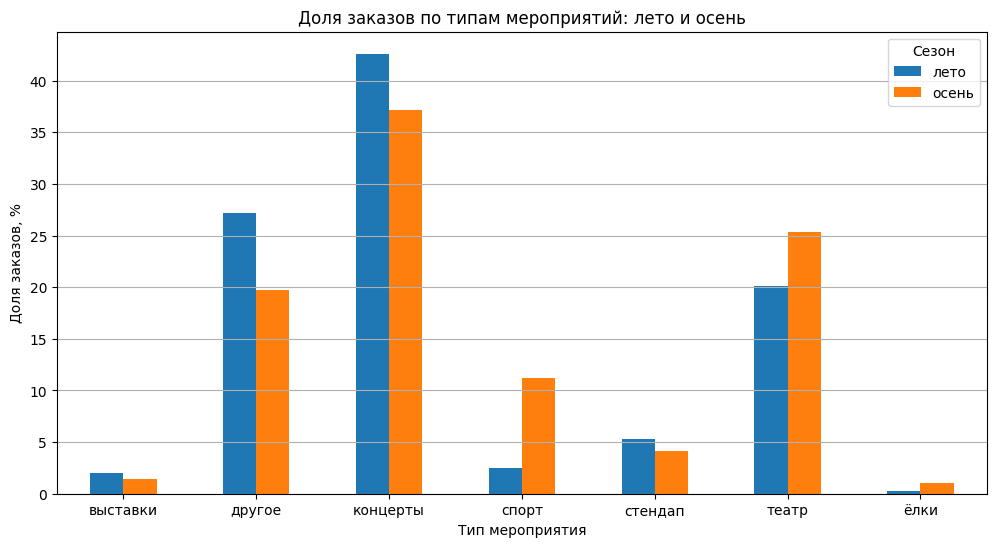

In [41]:
event_pivot = event_season.pivot(
    index="event_type_main", columns="season", values="share"
)

event_pivot.plot(kind="bar", figsize=(12, 6), rot=0)

plt.xlabel("Тип мероприятия")
plt.ylabel("Доля заказов, %")
plt.title("Доля заказов по типам мероприятий: лето и осень")
plt.legend(title="Сезон")
plt.grid(axis="y")

plt.show()

In [42]:
# посмотрим количество заказов и их доли по типам устройств по сезонам и визуализируем
device_season = (
    df[df["season"].isin(["лето", "осень"])]
    .groupby(["device_type_canonical", "season"])["order_id"]
    .count()
    .reset_index()
)

device_season["share"] = (
    device_season["order_id"]
    / device_season.groupby("season")["order_id"].transform("sum")
    * 100
)
device_season = round(device_season, 2)
device_season

,device_type_canonical,season,order_id,share
0,desktop,лето,23058,19.36
1,desktop,осень,34299,20.35
2,mobile,лето,96051,80.64
3,mobile,осень,134286,79.65


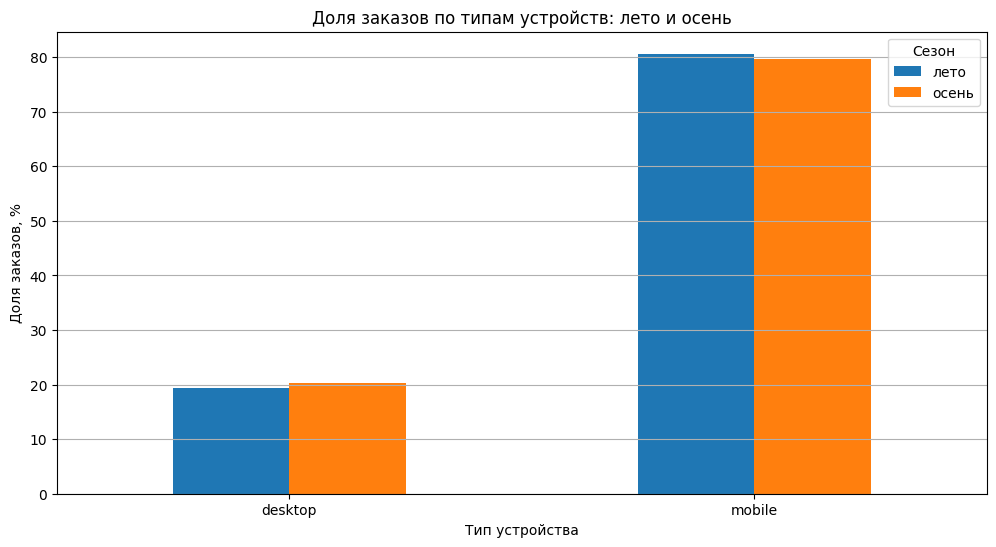

In [43]:
device_pivot = device_season.pivot(
    index="device_type_canonical", columns="season", values="share"
)

device_pivot.plot(kind="bar", figsize=(12, 6), rot=0)

plt.xlabel("Тип устройства")
plt.ylabel("Доля заказов, %")
plt.title("Доля заказов по типам устройств: лето и осень")
plt.legend(title="Сезон")
plt.grid(axis="y")

plt.show()

In [44]:
# посмотрим количество заказов и их доли по возрастному рейтингу по сезонам и визуализируем
age_limit_season = (
    df[df["season"].isin(["лето", "осень"])]
    .groupby(["age_limit", "season"])["order_id"]
    .count()
    .reset_index()
)

age_limit_season["share"] = (
    age_limit_season["order_id"]
    / age_limit_season.groupby("season")["order_id"].transform("sum")
    * 100
)
age_limit_season = round(age_limit_season, 2)
age_limit_season

,age_limit,season,order_id,share
0,0,лето,21404,17.97
1,0,осень,39828,23.62
2,6,лето,21672,18.20
3,6,осень,29720,17.63
4,12,лето,24453,20.53
5,12,осень,37217,22.08
6,16,лето,33756,28.34
7,16,осень,44217,26.23
8,18,лето,17824,14.96
9,18,осень,17603,10.44


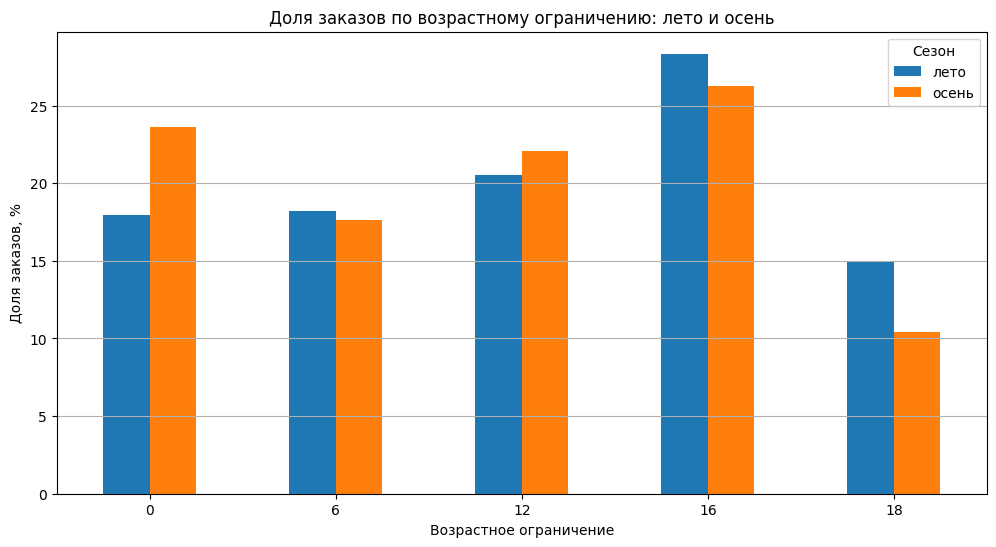

In [45]:
age_limit_pivot = age_limit_season.pivot(
    index="age_limit", columns="season", values="share"
)

age_limit_pivot.plot(kind="bar", figsize=(12, 6), rot=0)

plt.xlabel("Возрастное ограничение")
plt.ylabel("Доля заказов, %")
plt.title("Доля заказов по возрастному ограничению: лето и осень")
plt.legend(title="Сезон")
plt.grid(axis="y")

plt.show()


**Тип мероприятия**  
Концерты занимают наибольшую долю заказов в обоих сезонах, однако их доля снижается с 42,6% летом до 37,2% осенью.
Осенью заметно увеличивается доля спортивных мероприятий — с 2,5% до 11,2%, а также театра — с 20,1% до 25,4%.
Доля категории «другое» снижается с 27,2% до 19,7%.
Краткий вывод: осенью структура заказов становится более ориентированной на спорт и театр, тогда как летом большую долю занимают концерты и категория «другое».   
**Тип устройства**  
В обоих сезонах подавляющее большинство заказов оформляется с мобильных устройств: 80,6% летом и 79,7% осенью.
Доля заказов с desktop немного увеличивается осенью — с 19,4% до 20,4%.
Краткий вывод: распределение практически не меняется — около 80% заказов приходится на mobile независимо от сезона.  
**Возрастной рейтинг**  
Наибольшую долю заказов в обоих сезонах составляют мероприятия с рейтингом 16+: 28,3% летом и 26,2% осенью.
Осенью увеличивается доля заказов на мероприятия 0+ — с 18,0% до 23,6%, и 12+ — с 20,5% до 22,1%.
При этом заметно снижается доля мероприятий 18+ — с 15,0% летом до 10,4% осенью.
Краткий вывод: структура заказов по возрастному рейтингу в целом сохраняется, но осенью увеличивается доля мероприятий 0+ и 12+, тогда как спрос на 18+ снижается.


#### 3.1.3 Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

In [46]:
one_ticket_season = (
    df[df["season"].isin(["лето", "осень"])]
    .groupby(["event_type_main", "season"])["one_ticket_revenue_rub"]
    .mean()
    .reset_index()
)
one_ticket_season

,event_type_main,season,one_ticket_revenue_rub
0,выставки,лето,86.416198
1,выставки,осень,90.603610
2,другое,лето,77.433968
3,другое,осень,76.115334
4,концерты,лето,304.717078
5,концерты,осень,268.084074
6,спорт,лето,50.761831
7,спорт,осень,49.969733
8,стендап,лето,218.518107
9,стендап,осень,231.124973


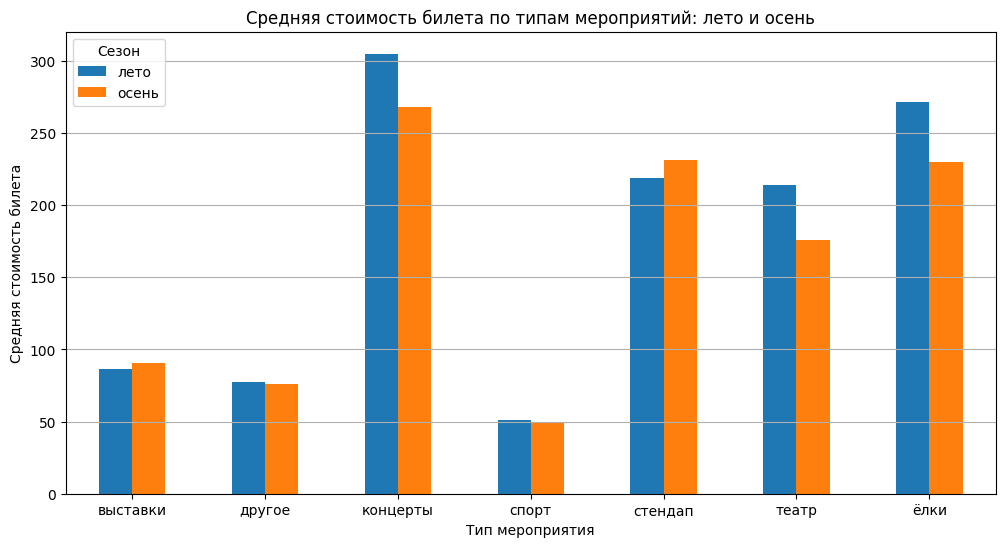

In [47]:
one_ticket_pivot = one_ticket_season.pivot(
    index="event_type_main", columns="season", values="one_ticket_revenue_rub"
)
one_ticket_pivot.plot(kind="bar", figsize=(12, 6), rot=0)

plt.xlabel("Тип мероприятия")
plt.ylabel("Средняя стоимость билета")
plt.title("Средняя стоимость билета по типам мероприятий: лето и осень")
plt.legend(title="Сезон")
plt.grid(axis="y")

plt.show()

In [48]:
one_ticket_change = one_ticket_season.pivot(
    index="event_type_main", columns="season", values="one_ticket_revenue_rub"
).reset_index()

one_ticket_change["change_season"] = (
    (one_ticket_change["осень"] - one_ticket_change["лето"])
    / one_ticket_change["лето"]
    * 100
)

one_ticket_change

season,event_type_main,лето,осень,change_season
0,выставки,86.416198,90.603610,4.845634
1,другое,77.433968,76.115334,-1.702914
2,концерты,304.717078,268.084074,-12.021973
3,спорт,50.761831,49.969733,-1.560421
4,стендап,218.518107,231.124973,5.769255
5,театр,214.126333,175.969508,-17.819772
6,ёлки,271.436176,229.585589,-15.418205


Средняя выручка с одного билета изменяется при переходе от лета к осени и динамика различается в зависимости от типа мероприятия.  
Рост средней выручки наблюдается у двух категорий: выставок — с 86,42 до 90,60 ₽ (+4,85%) и стендапа — с 218,52 до 231,12 ₽ (+5,77%).
В остальных категориях показатель снизился. Наиболее существенное снижение наблюдается у театра — с 214,13 до 175,97 ₽ (−17,82%), ёлок — с 271,44 до 229,59 ₽ (−15,42%) и концертов — с 304,72 до 268,08 ₽ (−12,02%). Для категорий «другое» и «спорт» изменение незначительное — около −1,7% и −1,6% соответственно.  
Таким образом, изменение средней стоимости одного билета с наступлением осени неоднородно: в большинстве категорий она снизилась, тогда как у выставок и стендапа выросла. При этом по данной таблице можно сделать вывод только об изменении средней выручки с одного билета, но не о перераспределении количества заказов между категориями.

### 3.2 Осенняя активность пользователей

#### 3.2.1 Изучиv активность пользователей осенью 2024 года

In [49]:
# создадим датафрейм с данными за осень 2024
df_autumn = df[df["season"] == "осень"].copy()

In [50]:
daily_activity = (
    df_autumn.groupby("created_dt_msk")
    .agg(
        orders=("order_id", "nunique"),
        dau=("user_id", "nunique"),
        avg_ticket=("one_ticket_revenue_rub", "mean"),
    )
    .reset_index()
)

daily_activity["orders_one_user"] = daily_activity["orders"] / daily_activity["dau"]

In [51]:
daily_activity

,created_dt_msk,orders,dau,avg_ticket,orders_one_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5111,778,80.130097,6.569409
3,2024-09-04,1772,685,177.785850,2.586861
4,2024-09-05,1944,739,189.510156,2.630582
...,...,...,...,...,...
56,2024-10-27,2849,1034,186.968328,2.755319
57,2024-10-28,2838,985,170.654940,2.881218
58,2024-10-29,2836,998,177.409612,2.841683
59,2024-10-30,2927,1039,182.791483,2.817132


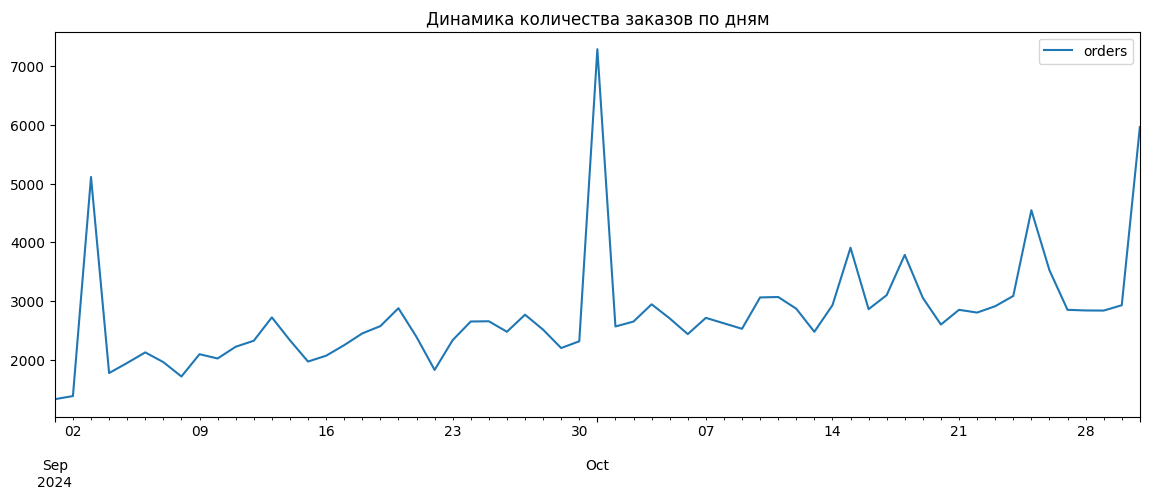

In [52]:
daily_activity.plot(x="created_dt_msk", y="orders", figsize=(14, 5))
plt.title("Динамика количества заказов по дням")
plt.xlabel("")
plt.show()

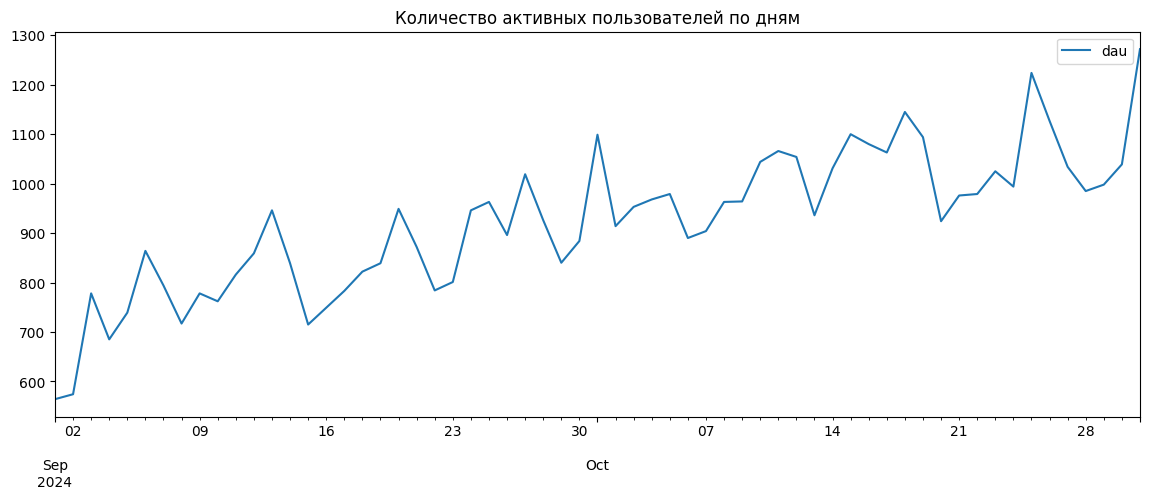

In [53]:
daily_activity.plot(x="created_dt_msk", y="dau", figsize=(14, 5))
plt.title("Количество активных пользователей по дням")
plt.xlabel("")
plt.show()

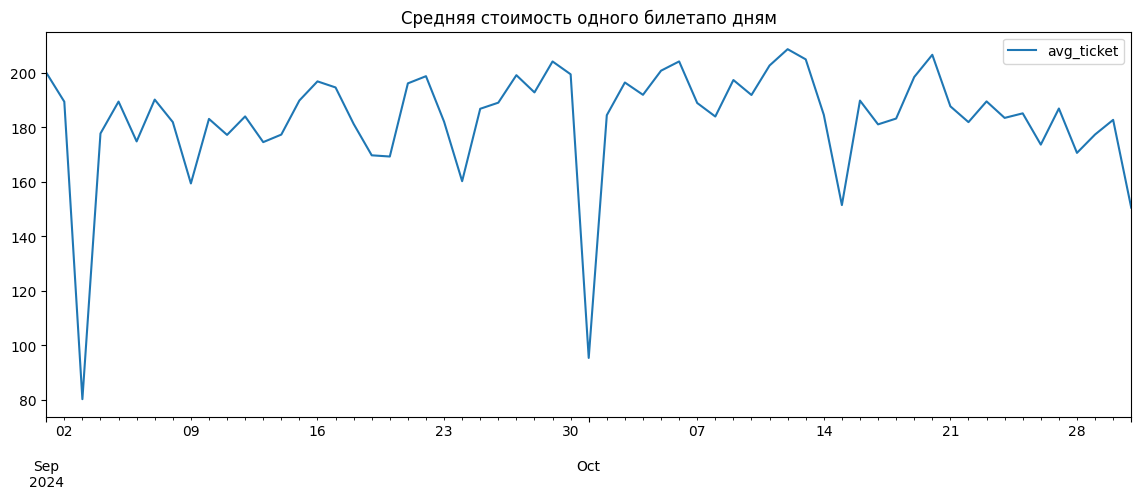

In [54]:
daily_activity.plot(x="created_dt_msk", y="avg_ticket", figsize=(14, 5))
plt.title("Средняя стоимость одного билетапо дням")
plt.xlabel("")
plt.show()

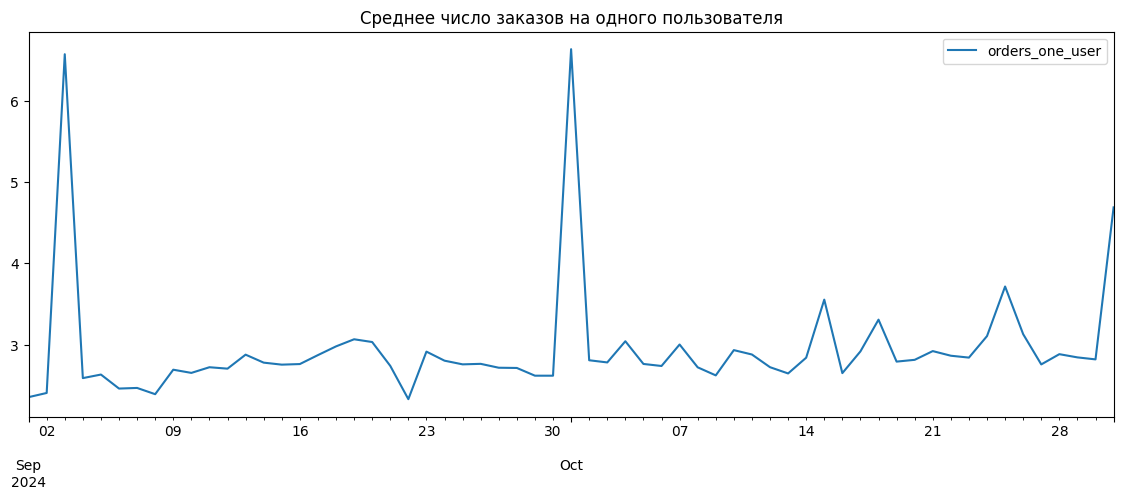

In [55]:
daily_activity.plot(x="created_dt_msk", y="orders_one_user", figsize=(14, 5))
plt.title("Среднее число заказов на одного пользователя")
plt.xlabel("")
plt.show()

Выводы  
В течение осени пользовательская активность увеличивалась: количество активных пользователей выросло с 564 человек 1 сентября до 1 272 человек 31 октября.  
Вместе с DAU увеличивалось и количество заказов: в начале сентября обычно было около 1,3–2,5 тыс. заказов в день, а в октябре — чаще 2,5–3,5 тыс.  
Среднее количество заказов на одного пользователя большую часть периода составляло около 2,5–3 заказов в день. В отдельные дни показатель был значительно выше — до 6,63 заказа на пользователя 1 октября.  
Средняя стоимость одного билета в течение периода заметно колебалась, в большинстве дней находясь примерно в диапазоне 170–205 ₽.
Наиболее заметные пики активности сопровождались снижением средней стоимости билета. Например, 1 октября было 7 288 заказов, 1 099 активных пользователей и средняя стоимость билета 95,29 ₽.  
Таким образом, осенью наблюдается рост активности пользователей и количества заказов, при этом средняя стоимость билета не демонстрирует устойчивого роста и существенно меняется от дня к дню.  
Отдельного внимания требуют аномальные даты 3 сентября и 1 октября — их стоит дополнительно исследовать по типам событий, поскольку они существенно отличаются от остальных дней  

#### 3.2.1 Изучим недельную цикличность

In [56]:
df_autumn["day_of_week"] = df_autumn["created_dt_msk"].dt.dayofweek

In [57]:
days = {
    0: "понедельник",
    1: "вторник",
    2: "среда",
    3: "четверг",
    4: "пятница",
    5: "суббота",
    6: "воскресенье",
}

df_autumn["day_name"] = df_autumn["day_of_week"].map(days)

In [58]:
df_autumn["day_type"] = np.where(
    df_autumn["created_dt_msk"].dt.dayofweek >= 5, "выходные", "будни"
)

In [59]:
df_autumn.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,age_limit,currency_code,device_type_canonical,revenue,service_name,...,venue_address,data,curs,revenue_rub,one_ticket_revenue_rub,month,season,day_of_week,day_name,day_type
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,0,rub,mobile,1258.57,За билетом!,...,"алл. Юбилейная, д. 5/6",2024-10-06,19.6475,1258.57,314.642500,10,осень,6,воскресенье,выходные
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,18,rub,mobile,1390.41,Билеты без проблем,...,"ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648,1390.41,463.470000,10,осень,4,пятница,будни
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,12,rub,mobile,902.74,Облачко,...,"бул. Отрадный, д. 4 стр. 1",2024-10-23,20.0531,902.74,300.913333,10,осень,2,среда,будни
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,12,rub,mobile,47.78,Лучшие билеты,...,"ул. О.Кошевого, д. 7",2024-09-29,19.3741,47.78,47.780000,9,осень,6,воскресенье,выходные
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,12,rub,mobile,74.84,Лучшие билеты,...,"ул. О.Кошевого, д. 7",2024-10-15,19.7185,74.84,37.420000,10,осень,1,вторник,будни


In [60]:
weekday_activity = (
    df_autumn.groupby(["created_dt_msk", "day_type"])
    .agg(orders=("order_id", "nunique"), dau=("user_id", "nunique"))
    .reset_index()
    .groupby("day_type")
    .agg(avg_orders=("orders", "mean"), avg_dau=("dau", "mean"))
    .reset_index()
)

weekday_activity["avg_orders_per_user"] = (
    weekday_activity["avg_orders"] / weekday_activity["avg_dau"]
)

weekday_activity = weekday_activity.round(2)

weekday_activity

,day_type,avg_orders,avg_dau,avg_orders_per_user
0,будни,2906.00,937.23,3.1
1,выходные,2395.35,887.59,2.7


In [61]:
day_activity = (
    df_autumn.groupby(["created_dt_msk", "day_of_week", "day_name"])
    .agg(orders=("order_id", "nunique"), dau=("user_id", "nunique"))
    .reset_index()
)

day_activity["orders_per_user"] = day_activity["orders"] / day_activity["dau"]

day_activity = (
    day_activity.groupby(["day_of_week", "day_name"])
    .agg(
        avg_orders=("orders", "mean"),
        avg_dau=("dau", "mean"),
        avg_orders_per_user=("orders_per_user", "mean"),
    )
    .reset_index()
    .sort_values("day_of_week")
    .round(2)
)

day_activity

,day_of_week,day_name,avg_orders,avg_dau,avg_orders_per_user
0,0,понедельник,2390.11,853.56,2.78
1,1,вторник,3497.78,934.22,3.72
2,2,среда,2542.33,923.11,2.75
3,3,четверг,3018.44,962.11,3.06
4,4,пятница,3103.25,1022.62,3.00
5,5,суббота,2666.62,960.62,2.76
6,6,воскресенье,2154.22,822.67,2.60


В будние дни пользовательская активность выше, чем в выходные. Среднее число заказов в будни составляет 2 906 против 2 395 в выходные, а средний DAU — 937 против 888 пользователей. Также в будни пользователи совершают в среднем 3,1 заказа на пользователя против 2,7 в выходные. Таким образом, активность и интенсивность заказов снижаются в выходные примерно на 18% по числу заказов, на 5% по DAU и на 13% по числу заказов на пользователя.

Пользовательская активность имеет выраженную недельную цикличность. Максимальная активность наблюдается во вторник: в среднем 3 497,78 заказа, 934,22 активного пользователя и 3,72 заказа на пользователя в день. К концу недели активность снижается, а минимальные значения приходятся на воскресенье — 2 154,22 заказа, 822,67 активного пользователя и 2,60 заказа на пользователя. В пятницу наблюдается максимальный средний DAU — 1 022,62 пользователя, однако интенсивность заказов на одного пользователя ниже, чем во вторник и четверг. В целом будние дни характеризуются более высокой активностью и интенсивностью заказов, тогда как в выходные показатели снижаются.

### 3.3 Популярные события и партнёры
#### 3.3.1 Уникальное количество мероприятий и общее число заказов по регионам

In [62]:
df_autumn.info()

<class 'pandas.DataFrame'>
Index: 168585 entries, 2 to 287693
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                168585 non-null  int64         
 1   user_id                 168585 non-null  str           
 2   created_dt_msk          168585 non-null  datetime64[us]
 3   created_ts_msk          168585 non-null  datetime64[us]
 4   event_id                168585 non-null  int64         
 5   age_limit               168585 non-null  int64         
 6   currency_code           168585 non-null  str           
 7   device_type_canonical   168585 non-null  str           
 8   revenue                 168585 non-null  float64       
 9   service_name            168585 non-null  str           
 10  tickets_count           168585 non-null  int64         
 11  total                   168585 non-null  float64       
 12  days_since_prev         160244 non-null  float

In [63]:
df_region = df_autumn.groupby("region_name").agg(
    event=("event_id", "nunique"), orders=("order_id", "nunique")
)

df_region["events_share"] = df_region["event"] / df_region["event"].sum() * 100

df_region["orders_share"] = df_region["orders"] / df_region["orders"].sum() * 100

df_region = df_region.sort_values("event", ascending=False).reset_index().round(2)
df_region.head(20)

,region_name,event,orders,events_share,orders_share
0,Каменевский регион,3910,46684,24.63,27.69
1,Североярская область,2613,20718,16.46,12.29
2,Широковская область,803,8715,5.06,5.17
3,Светополянский округ,764,4779,4.81,2.83
4,Речиновская область,529,3565,3.33,2.11
5,Серебринская область,456,4467,2.87,2.65
6,Яблоневская область,432,4199,2.72,2.49
7,Тепляковская область,419,2485,2.64,1.47
8,Горицветская область,406,3230,2.56,1.92
9,Солнечноземская область,403,4228,2.54,2.51


#### 3.3.2 Уникальное количество мероприятий, общее число заказовб сумма выручки для билетного партнера

In [64]:
df_partner = df_autumn.groupby("service_name").agg(
    event=("event_id", "nunique"),
    orders=("order_id", "nunique"),
    revenue_mln=("revenue_rub", "sum"),
)
df_partner["revenue_mln"] = df_partner["revenue_mln"] / 1_000_000

df_partner["events_share"] = round(
    df_partner["event"] / df_partner["event"].sum() * 100, 2
)

df_partner["orders_share"] = round(
    df_partner["orders"] / df_partner["orders"].sum() * 100, 2
)

df_partner = df_partner.sort_values("event", ascending=False).reset_index()
df_partner.head(20)

,service_name,event,orders,revenue_mln,events_share,orders_share
0,Лови билет!,3616,25792,10.376793,20.90,15.30
1,Билеты без проблем,2847,32383,12.116005,16.46,19.21
2,Билеты в руки,2469,25728,7.613383,14.27,15.26
3,Облачко,1409,15478,10.611052,8.15,9.18
4,Лучшие билеты,1396,12432,1.676010,8.07,7.37
5,Мой билет,1005,19416,10.850676,5.81,11.52
6,Тебе билет!,859,3749,2.137900,4.97,2.22
7,Прачечная,728,5798,2.548310,4.21,3.44
8,Весь в билетах,599,9406,9.325571,3.46,5.58
9,Яблоко,537,3473,2.763332,3.10,2.06


#### 3.3.3 Выводы

Распределение мероприятий и заказов осенью 2024 года характеризуется заметной концентрацией активности как по регионам, так и по билетным партнёрам. Среди регионов выделяются Каменевский регион и Североярская область: на них приходится около 41% всех мероприятий и 40% заказов. При этом вклад отдельных регионов не всегда соответствует количеству представленных мероприятий — в некоторых регионах относительно небольшое число мероприятий обеспечивает значительную долю заказов.

Среди билетных партнёров также наблюдаются выраженные лидеры. Наибольшую долю мероприятий представляет «Лови билет!» (20,90%), а по количеству заказов лидирует «Билеты без проблем» (19,21%). Наибольшую выручку среди представленных партнёров формируют «Билеты без проблем» — 12,12 млн руб., «Мой билет» — 10,85 млн руб., «Облачко» — 10,61 млн руб. и «Лови билет!» — 10,38 млн руб. При этом количество мероприятий не всегда соответствует объёму выручки: например, «Мой билет» представлен 5,81% мероприятий, но формирует 10,85 млн руб. выручки, тогда как «Лучшие билеты» имеют 8,07% мероприятий, но выручка составляет только 1,68 млн руб. Это показывает различия в объёме выручки, приходящейся на мероприятия и заказы разных партнёров.

Таким образом, явные лидеры существуют и среди регионов, и среди партнёров, однако распределение активности не является полностью концентрированным. Основной объём мероприятий и заказов формируется ограниченной группой регионов и партнёров, тогда как остальные участники имеют значительно меньшие доли. При этом различия между долями мероприятий и заказов показывают, что масштаб предложения не всегда напрямую связан с фактической активностью пользователей.


## 4. Статистический анализ данных
### 4.1 Проверка гипотезы: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств

**H₀ (нулевая гипотеза):** Среднее количество заказов на одного пользователя мобильного приложения не выше по сравнению с пользователями стационарных устройств   
**H₁ (альтернативная гипотеза):** Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств

In [65]:
user_orders = (
    df_autumn.groupby(["device_type_canonical", "user_id"])
    .agg(orders=("order_id", "nunique"))
    .reset_index()
)

In [66]:
# пользователи каждой группы
desktop_users = set(
    user_orders.loc[user_orders["device_type_canonical"] == "desktop", "user_id"]
)

mobile_users = set(
    user_orders.loc[user_orders["device_type_canonical"] == "mobile", "user_id"]
)

# пересекающиеся пользователи
common_users = desktop_users & mobile_users

print("Пересекающихся пользователей:", len(common_users))

Пересекающихся пользователей: 3248


In [67]:
# оставляем только пользователей, которые использовали одно устройство
desktop_unique = desktop_users - common_users
mobile_unique = mobile_users - common_users

print("Пользователей desktop:", len(desktop_unique))
print("Пользователей mobile:", len(mobile_unique))

Пользователей desktop: 1620
Пользователей mobile: 10940


In [68]:
desktop = user_orders.loc[
    (user_orders["device_type_canonical"] == "desktop")
    & (user_orders["user_id"].isin(desktop_unique)),
    "orders",
]

mobile = user_orders.loc[
    (user_orders["device_type_canonical"] == "mobile")
    & (user_orders["user_id"].isin(mobile_unique)),
    "orders",
]

# t-тест
stat, p_value = ttest_ind(mobile, desktop, equal_var=False, alternative="greater")

alpha = 0.05

print(f"Среднее количество заказов на пользователя desktop: {desktop.mean():.2f}")
print(f"Среднее количество заказов на пользователя mobile: {mobile.mean():.2f}")
print(f"Разница: {mobile.mean() - desktop.mean():.2f}")
print(f"p-value: {p_value}")

if p_value < alpha:
    print("Разница статистически значима")
else:
    print("Разница статистически незначима")

Среднее количество заказов на пользователя desktop: 1.97
Среднее количество заказов на пользователя mobile: 2.86
Разница: 0.88
p-value: 7.163336265354689e-25
Разница статистически значима


Среднее количество заказов на одного пользователя мобильного приложения составляет 2,86, что на 0,89 заказа больше, чем у пользователей стационарных устройств (1,97). По результатам t-теста Уэлча различие статистически значимо (p-value < 0,05). Таким образом, данные поддерживают гипотезу о том, что пользователи мобильного приложения в среднем совершают больше заказов.


### 4.2 Проверка гипотезы: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

**H₀ (нулевая гипотеза):** Среднее время между заказами пользователей мобильных приложений не выше по сравнению с пользователями стационарных устройств   
**H₁ (альтернативная гипотеза):** Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств 

In [69]:
# сгрупируем по пользователям и видам устройств
user_time = (
    df_autumn.groupby(["device_type_canonical", "user_id"])
    .agg(avg_days_between_orders=("days_since_prev", "mean"))
    .reset_index()
    .dropna(subset=["avg_days_between_orders"])
)

In [70]:
# найдем пересечения и удалим их
desktop_users = set(
    user_time[user_time["device_type_canonical"] == "desktop"]["user_id"]
)

mobile_users = set(user_time[user_time["device_type_canonical"] == "mobile"]["user_id"])

# количество пользователей, которые есть в обеих группах
len(desktop_users & mobile_users)

3028

In [71]:
# пользователи, которые заказывали с обоих устройств
common_users = desktop_users & mobile_users

# оставляем только уникальных пользователей каждой группы
desktop_unique = desktop_users - common_users
mobile_unique = mobile_users - common_users

In [72]:
len(desktop_unique & mobile_unique)

0

In [73]:
print("Пользователей desktop:", len(desktop_unique))
print("Пользователей mobile:", len(mobile_unique))

Пользователей desktop: 1005
Пользователей mobile: 7164


In [74]:
desktop = user_time[
    (user_time["device_type_canonical"] == "desktop")
    & (user_time["user_id"].isin(desktop_unique))
]["avg_days_between_orders"]

mobile = user_time[
    (user_time["device_type_canonical"] == "mobile")
    & (user_time["user_id"].isin(mobile_unique))
]["avg_days_between_orders"]

stat, p_value = ttest_ind(mobile, desktop, equal_var=False, alternative="greater")

alpha = 0.05

print(f"Среднее время между заказами desktop: {desktop.mean():.2f} дней")
print(f"Среднее время между заказами mobile: {mobile.mean():.2f} дней")
print(f"Разница: {mobile.mean() - desktop.mean():.2f} дней")
print(f"p-value: {p_value}")

if p_value < alpha:
    print("Разница статистически значима")
else:
    print("Разница статистически незначима")

Среднее время между заказами desktop: 29.55 дней
Среднее время между заказами mobile: 25.06 дней
Разница: -4.48 дней
p-value: 0.9999378997658087
Разница статистически незначима


Среднее время между заказами пользователей мобильных приложений составляет 25,06 дней, что на 4,49 дня меньше, чем у пользователей стационарных устройств (29,55 дней). По результатам t-теста Уэлча различие статистически не значимо (p-value > 0,05). Таким образом, данные подтверждают гипотезу о том, что среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.


## 5. Общий вывод и рекомендации

### Общий вывод

В ходе анализа были изучены данные о заказах билетов на мероприятия за июнь–октябрь 2024 года. После предобработки, удаления дубликатов и выбросов по выручке, объединения данных о заказах, мероприятиях и курсах валют в итоговом датасете осталось **287 694 строки и 29 столбцов**. Были рассчитаны дополнительные признаки, в том числе выручка в рублях, выручка на один билет, месяц и сезон заказа.

В течение рассматриваемого периода количество заказов заметно увеличивалось: с **34,2 тыс. в июне до 99,3 тыс. в октябре**. Наиболее выраженный рост наблюдается с сентября. Осенью структура спроса также меняется: доля концертов остаётся крупнейшей, но снижается с **42,6% до 37,2%**, тогда как увеличивается доля спортивных мероприятий (**с 2,5% до 11,2%**) и театра (**с 20,1% до 25,4%**).

Средняя выручка с одного билета меняется неодинаково в зависимости от типа мероприятия. Рост наблюдается у выставок (**+4,85%**) и стендапа (**+5,77%**), тогда как наиболее заметное снижение приходится на театр (**−17,82%**), ёлки (**−15,42%**) и концерты (**−12,02%**). При этом около **80% заказов** в обоих сезонах оформляется с мобильных устройств.

Осенью наблюдается рост пользовательской активности: количество активных пользователей увеличивается с **564 в начале сентября до 1 272 к концу октября**, одновременно растёт число заказов. Активность имеет выраженную недельную цикличность: в будние дни среднее количество заказов составляет **2 906 против 2 395 в выходные**, а средний DAU — **937 против 888**. Максимальная средняя активность приходится на вторник — **3 497,78 заказа и 934,22 активного пользователя**, минимальная — на воскресенье. Отдельного внимания требуют аномальные даты **3 сентября и 1 октября**, показатели которых существенно отличаются от остальных дней.

Распределение активности по регионам и билетным партнёрам неоднородно. Каменевский регион и Североярская область формируют около **41% мероприятий и 40% заказов**. Среди партнёров по количеству мероприятий лидирует «Лови билет!» (**20,90%**), по количеству заказов — «Билеты без проблем» (**19,21%**), а наибольшую выручку получают «Билеты без проблем» (**12,12 млн руб.**), «Мой билет» (**10,85 млн руб.**) и «Облачко» (**10,61 млн руб.**). При этом количество мероприятий не всегда соответствует объёму заказов и выручки, что указывает на различия в востребованности предложений.

Проверка гипотез показала, что среднее количество заказов на одного пользователя mobile статистически значимо выше, чем у пользователей desktop: **2,86 против 1,97 заказа на пользователя**, разница составляет 0,88 заказа. При этом среднее время между заказами у mobile-пользователей составляет **25,06 дня против 29,55 дня** у desktop-пользователей, однако выявленная разница в **4,48 дня** не является статистически значимой. Таким образом, пользователи mobile совершают больше заказов в среднем, но статистически значимых различий во времени между заказами по сравнению с desktop не выявлено.


### Рекомендации

1. **Уделить особое внимание мобильной аудитории.** На мобильные устройства приходится около 80% заказов, а среднее количество заказов на одного пользователя статистически значимо выше, чем у desktop-аудитории: 2,86 против 1,97 заказа. При этом статистически значимых различий во времени между заказами не выявлено. Поэтому целесообразно развивать мобильный канал и использовать его для стимулирования повторных заказов и удержания пользователей.

2. **Исследовать причины пиков активности.** В первую очередь стоит дополнительно изучить 3 сентября и 1 октября: определить, какие мероприятия, регионы и партнёры сформировали аномальный рост заказов и пользователей. Это позволит понять причины пиков и использовать аналогичные механики в дальнейшем.

3. **Учитывать сезонность и структуру спроса при продвижении мероприятий.** Осенью заметно увеличивается доля спортивных мероприятий и театра, поэтому при планировании продвижения стоит учитывать изменение интересов аудитории.

4. **Выделить партнёров с высокой эффективностью продаж.** При анализе партнёров стоит сравнивать доли мероприятий, заказов и выручки. Например, «Мой билет» имеет **5,81% мероприятий, но 11,52% заказов и 10,85 млн руб. выручки**, что показывает высокий спрос на представленные через него мероприятия. Такой анализ поможет определить партнёров, которые при относительно небольшом количестве мероприятий обеспечивают значительную часть продаж.

5. **Учитывать недельную сезонность активности.** Более высокая активность в будние дни, особенно во вторник, может использоваться при планировании рекламных кампаний, рассылок и других активностей по привлечению пользователей.
